## 1. Imports

Load the libraries required for final model evaluation, visualization,
and model interpretation.

In [1]:
# ==========================================
# IMPORTS
# ==========================================

import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

## 2. Load Test Data and Selected Model

Load the untouched test dataset and the trained model produced by
`03_modeling.ipynb`.

In [3]:
# Load test data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load selected trained model
model = joblib.load('../models/churn_model.pkl')

print("Test data:", X_test.shape)
print("Model loaded:", type(model).__name__)

Test data: (1409, 38)
Model loaded: LogisticRegression


## 3. Generate Final Predictions

Generate predicted classes and churn probabilities from the selected model.

In [5]:
# Generate predictions
y_pred = model.predict(X_test)

# Probability of the positive class: Churn
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 4. Final Performance Metrics

Calculate the primary classification metrics for the selected model.

In [6]:
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}

metrics_df = pd.DataFrame(
    [final_metrics],
    index=['Selected Model']
)

metrics_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Selected Model,0.804826,0.655172,0.558824,0.603175,0.842807


## 5. Classification Report

Inspect precision, recall, and F1-score separately for both classes.

This is particularly important for churn because the cost of missing a
customer who is likely to churn may differ from incorrectly targeting
a customer who would have stayed.

In [7]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No Churn', 'Churn']
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## 6. Confusion Matrix

Analyze the types of predictions made by the model.

The confusion matrix separates correct predictions from false positives
and false negatives.

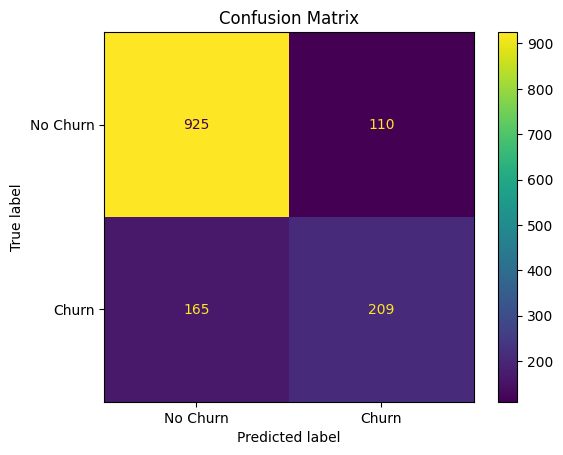

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title('Confusion Matrix')
plt.show()

## 7. ROC Curve

Evaluate how effectively the model separates churners from non-churners
across different classification thresholds.

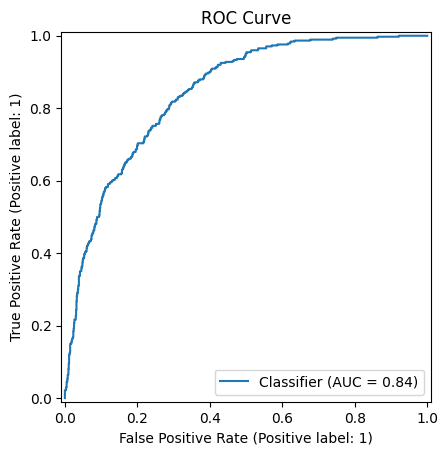

In [15]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('ROC Curve')
plt.show()

## 8. Precision-Recall Curve

Examine the trade-off between identifying churners and avoiding false
positive churn predictions across different probability thresholds.

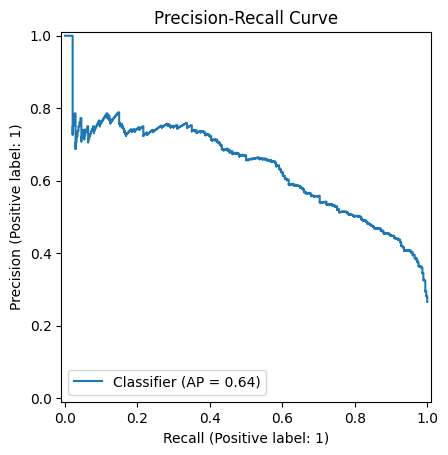

In [16]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('Precision-Recall Curve')
plt.show()

## 9. Classification Threshold Analysis

The default classification threshold is 0.50.

Evaluate how changing the threshold affects precision and recall.

In [17]:
import numpy as np

thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:

    y_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test,
            y_threshold,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            y_threshold,
            zero_division=0
        ),
        'F1': f1_score(
            y_test,
            y_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.468613,0.858289,0.606232
1,0.25,0.495146,0.818182,0.616935
2,0.30,0.519266,0.756684,0.615887
3,0.35,0.541152,0.703209,0.611628
4,0.40,0.565315,0.671123,0.613692
5,0.45,0.601562,0.617647,0.609499
6,0.50,0.655172,0.558824,0.603175
7,0.55,0.675781,0.462567,0.549206
8,0.60,0.723301,0.398396,0.513793
9,0.65,0.748344,0.302139,0.430476


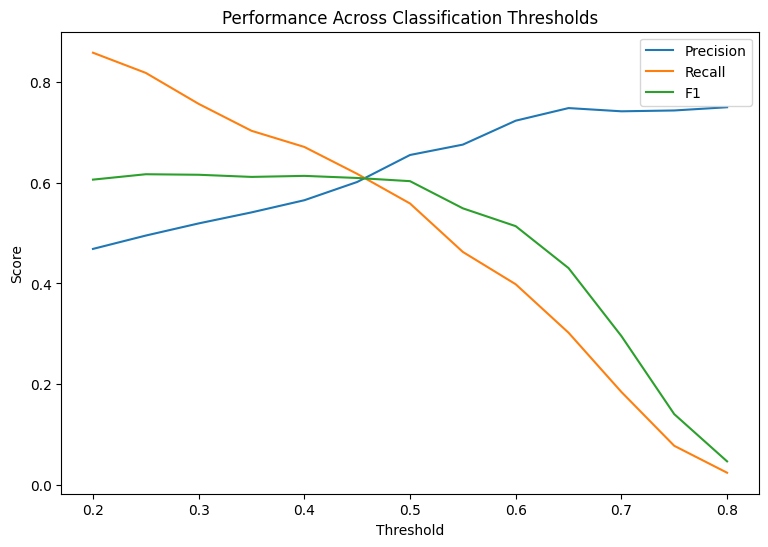

In [18]:
threshold_df.plot(
    x='Threshold',
    y=['Precision', 'Recall', 'F1'],
    figsize=(9, 6)
)

plt.title('Performance Across Classification Thresholds')
plt.ylabel('Score')
plt.show()

In [19]:
#“A lower threshold increases churn detection but also increases false positives.”

## 9. Error Analysis

Inspect incorrectly classified customers to understand where the model
struggles and identify potential patterns in prediction errors.

In [22]:
# Create an evaluation DataFrame
error_analysis = X_test.copy()

error_analysis['Actual_Churn'] = y_test.values
error_analysis['Predicted_Churn'] = y_pred
error_analysis['Churn_Probability'] = y_prob

# Mark incorrect predictions
error_analysis['Correct'] = (
    error_analysis['Actual_Churn']
    == error_analysis['Predicted_Churn']
)

errors = error_analysis[
    ~error_analysis['Correct']
].copy()

print("Total test observations:", len(error_analysis))
print("Incorrect predictions :", len(errors))
print("Error rate             :", len(errors) / len(error_analysis))

errors.head()


Total test observations: 1409
Incorrect predictions : 275
Error rate             : 0.19517388218594747


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Predicted_Churn,Churn_Probability,Correct
1,0,1,0,0,8,1,0,1,100.15,908.55,...,0.0,1.0,0.0,1.0,0.0,0.0,0,1,0.684550,False
5,0,0,0,0,21,1,0,1,99.85,1992.55,...,0.0,1.0,0.0,1.0,0.0,0.0,0,1,0.600460,False
9,1,1,0,0,17,1,0,1,45.05,770.60,...,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0.388893,False
17,1,0,0,1,15,1,0,1,91.00,1430.05,...,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0.628142,False
36,1,1,0,0,2,1,0,0,44.95,85.15,...,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0.372446,False


## 10. False Negative Analysis

Identify customers who actually churned but were predicted as non-churners.

These represent customers the business potentially failed to identify
for retention intervention.

In [23]:
false_negatives = error_analysis[
    (error_analysis['Actual_Churn'] == 1) &
    (error_analysis['Predicted_Churn'] == 0)
].copy()

print("False negatives:", len(false_negatives))

false_negatives.head()

False negatives: 165


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Predicted_Churn,Churn_Probability,Correct
9,1,1,0,0,17,1,0,1,45.05,770.60,...,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0.388893,False
36,1,1,0,0,2,1,0,0,44.95,85.15,...,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0.372446,False
39,1,0,0,0,31,1,0,1,55.25,1715.65,...,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0.182760,False
49,0,0,0,0,23,1,0,0,75.60,1758.60,...,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0.411509,False
61,1,0,0,0,45,1,1,1,20.40,930.45,...,1.0,0.0,0.0,0.0,1.0,0.0,1,0,0.028256,False


## 11. False Positive Analysis

Identify customers predicted to churn who ultimately did not churn.

These cases may represent unnecessary retention interventions.

In [25]:
false_positives = error_analysis[
    (error_analysis['Actual_Churn'] == 0) &
    (error_analysis['Predicted_Churn'] == 1)
].copy()

print("False positives:", len(false_positives))

false_positives.head()

False positives: 110


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Predicted_Churn,Churn_Probability,Correct
1,0,1,0,0,8,1,0,1,100.15,908.55,...,0.0,1.0,0.0,1.0,0.0,0.0,0,1,0.684550,False
5,0,0,0,0,21,1,0,1,99.85,1992.55,...,0.0,1.0,0.0,1.0,0.0,0.0,0,1,0.600460,False
17,1,0,0,1,15,1,0,1,91.00,1430.05,...,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0.628142,False
41,1,0,1,0,2,1,0,1,91.45,171.45,...,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0.789398,False
46,0,0,0,0,8,1,0,1,75.25,576.70,...,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0.706919,False


## 13. Feature Importance

Identify the features that contribute most strongly to the selected model.

In [27]:
print(type(model).__name__)

LogisticRegression


In [29]:
coefficients = pd.Series(
    model.coef_[0],
    index=X_test.columns
).sort_values()

coefficients.head(15)

Contract                                  -0.696532
InternetService_DSL                       -0.446678
Dependents                                -0.255086
MultipleLines_No                          -0.190876
OnlineBackup_No internet service          -0.126514
DeviceProtection_No internet service      -0.126514
InternetService_No                        -0.126514
TechSupport_No internet service           -0.126514
StreamingMovies_No internet service       -0.126514
OnlineSecurity_No internet service        -0.126514
StreamingTV_No internet service           -0.126514
PaymentMethod_Credit card (automatic)     -0.104849
OnlineSecurity_Yes                        -0.074309
PaymentMethod_Bank transfer (automatic)   -0.070235
StreamingTV_No                            -0.065150
dtype: float64

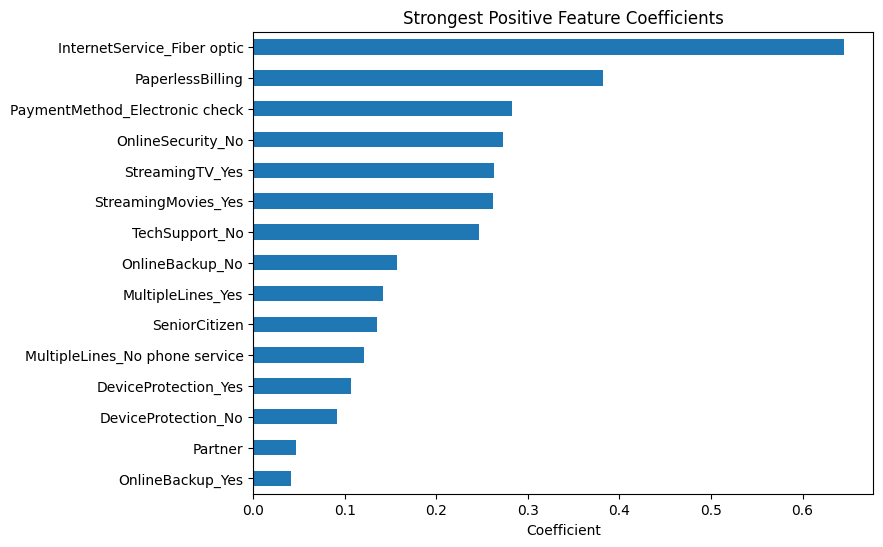

In [30]:
coefficients.tail(15).sort_values().plot(
    kind='barh',
    figsize=(8, 6)
)

plt.title('Strongest Positive Feature Coefficients')
plt.xlabel('Coefficient')
plt.show()

In [32]:
import os

os.makedirs('../reports', exist_ok=True)

metrics_df.to_csv(
    '../reports/final_model_metrics.csv'
)

threshold_df.to_csv(
    '../reports/threshold_analysis.csv',
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.
